<a href="https://colab.research.google.com/github/Rapsim/IPEO_DeepL_group15/blob/raph/question1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### code adapté de l'exo 9

In [1]:
COLAB = True

In [2]:
if COLAB:
    # Clone the repo !! only branch raph here !!
    !git clone -b raph --single-branch https://github.com/Rapsim/IPEO_DeepL_group15.git
    %cd IPEO_DeepL_group15

    # Install Python dependencies from the requirements file
    !pip install -r requirements.txt


Cloning into 'IPEO_DeepL_group15'...
remote: Enumerating objects: 122, done.
remote: Counting objects: 100% (122/122), done.
remote: Compressing objects: 100% (104/104), done.
remote: Total 122 (delta 32), reused 103 (delta 17), pack-reused 0 (from 0)
Receiving objects: 100% (122/122), 3.55 MiB | 11.41 MiB/s, done.
Resolving deltas: 100% (32/32), done.
/content/IPEO_DeepL_group15
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 117.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 16.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 76.7/76.7 kB 8.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.8/59.8 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 95.2 MB/s eta 0:00:00


In [3]:
if COLAB:
    from google.colab import drive
    drive.mount("/content/drive")

    import os

    # Must match the folder created in Drive
    data_root = "/content/drive/MyDrive/IPEO_DeepL_data"
    s2_dir = os.path.join(data_root, "S2")
    labels_dir = os.path.join(data_root, "labels")

    print("S2 dir:", s2_dir)
    print("Labels dir:", labels_dir)
    print("Number of S2 files:", len([f for f in os.listdir(s2_dir) if f.endswith(".tif")]))
    print("Number of label files:", len([f for f in os.listdir(labels_dir) if f.endswith(".tif")]))


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
S2 dir: /content/drive/MyDrive/IPEO_DeepL_data/S2
Labels dir: /content/drive/MyDrive/IPEO_DeepL_data/labels
Number of S2 files: 6000
Number of label files: 6000


In [4]:
import os
import torch
from torch.utils.data import dataset
from torch.utils.data import DataLoader
import numpy as np
import tifffile


In [5]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(device)

cuda


In [6]:

if not COLAB:
    # If not in colab, for small tests
    data_root = "sample"

### Process classes from csv

In [7]:
import pandas as pd
import os
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import numpy as np

# Load the CSV with label codes
csv_path = os.path.join(data_root, "Codigos-da-legenda-colecao-9.csv")
label_df = pd.read_csv(csv_path, delimiter='\t')

# Number of classes: 37 from CSV + 1 for "no data" (class 0)
NUM_CLASSES = len(label_df) + 1  # = 38
print(f"Number of classes: {NUM_CLASSES} (including class 0 for 'no data')")

# Create custom colormap from the CSV, including black for class 0
class_colors = [(0, 0, 0)]  # Black for "no data" (class 0)
class_names = ['No Data']
class_ids = [0]

for _, row in label_df.iterrows():
    class_ids.append(row['Class_ID'])
    class_names.append(row['Description'])
    # Convert hex color to RGB (0-1 range)
    hex_color = row['Color'].lstrip('#')
    rgb = tuple(int(hex_color[i:i+2], 16)/255.0 for i in (0, 2, 4))
    class_colors.append(rgb)

# Create ListedColormap
custom_cmap = ListedColormap(class_colors)

# Print class info
print("\nClass mapping:")
for class_id, name in zip(class_ids, class_names):
    print(f"{class_id}: {name}")

Number of classes: 38 (including class 0 for 'no data')

Class mapping:
0: No Data
1: Forest
3: Forest Formation
4: Savanna Formation
5: Mangrove
6: Floodable Forest
49: Wooded Sandbank Vegetation
10: Herbaceous and Shrubby Vegetation
11: Wetland
12: Grassland
32:  Hypersaline Tidal Flat
29:  Rocky Outcrop
50:  Herbaceous Sandbank Vegetation
14:  Farming
15:  Pasture
18:  Agriculture
19:  Temporary Crop
39:  Soybean
20:  Sugar cane
40:  Rice
62:  Cotton (beta)
41:  Other Temporary Crops
36:  Perennial Crop
46:  Coffee
47:  Citrus
35:  Palm Oil
48:  Other Perennial Crops
9:  Forest Plantation
21:  Mosaic of Uses
22:  Non vegetated area
23:  Beach, Dune and Sand Spot
24:  Urban Area
30:  Mining
25:  Other non Vegetated Areas
26:  Water
33:  River, Lake and Ocean
31:  Aquaculture
27:  Not Observed


In [8]:
label_df.head()

,Class_ID,Level,Description,Descricao,Color
0,1,1,Forest,Floresta,#32a65e
1,3,2,Forest Formation,Formação Florestal,#1f8d49
2,4,2,Savanna Formation,Formação Savânica,#7dc975
3,5,2,Mangrove,Mangue,#04381d
4,6,2,Floodable Forest,Floresta Alagável,#026975


## Compute images mean and std

In [9]:
def compute_s2_mean_std(s2_dir, file_prefix="train"):
    s2_files = sorted(
        f for f in os.listdir(s2_dir)
        if f.startswith(file_prefix) and f.endswith(".tif")
    )

    sum_band = None
    sumsq_band = None
    total_pixels = 0

    for i, fname in enumerate(s2_files):
        path = os.path.join(s2_dir, fname)
        img = tifffile.imread(path).astype(np.float32)

        # ensure (C,H,W)
        if img.ndim == 2:
            img = img[np.newaxis, ...]
        elif img.ndim == 3 and img.shape[-1] in (12, 13):
            img = np.transpose(img, (2, 0, 1))  # (H,W,C)->(C,H,W)

        img = img / 10000.0  # scale to approx [0,1]
        C, H, W = img.shape

        if sum_band is None:
            sum_band = np.zeros(C, dtype=np.float64)
            sumsq_band = np.zeros(C, dtype=np.float64)

        flat = img.reshape(C, -1)
        sum_band += flat.sum(axis=1)
        sumsq_band += (flat**2).sum(axis=1)
        total_pixels += H * W

    mean = sum_band / total_pixels
    var = sumsq_band / total_pixels - mean**2
    std = np.sqrt(np.maximum(var, 1e-12))

    return mean, std

# Example: use on small training sample S2 folder
# s2_dir_for_stats = "/content/drive/MyDrive/IPEO_DeepL_data/sample/S2"
s2_dir_for_stats = "sample/S2"
S2_MEAN, S2_STD = compute_s2_mean_std(s2_dir_for_stats, file_prefix="train")
print("S2_MEAN:", S2_MEAN)
print("S2_STD:", S2_STD)


S2_MEAN: [0.1139377  0.0890742  0.08113043 0.06680196 0.09717837 0.19016036
 0.23556764 0.2318273  0.27211989 0.05309604 0.18734722 0.08958261]
S2_STD: [0.00712784 0.01266245 0.01809968 0.03474503 0.03448118 0.03047756
 0.0388264  0.04093171 0.04471077 0.01083777 0.08132065 0.05494784]


In [16]:
!pip install -q imagecodecs

### Trying faster version

In [10]:
import os
import numpy as np
import tifffile
from concurrent.futures import ThreadPoolExecutor
from functools import partial

def compute_s2_mean_std_fast(s2_dir, file_prefix="train", num_workers=4, sample_ratio=None):
    """
    Efficiently compute mean/std for large datasets.

    Args:
        s2_dir: directory containing .tif files
        file_prefix: filter files by prefix
        num_workers: parallel workers for I/O
        sample_ratio: if set (e.g., 0.1), only use 10% of files for estimation
    """
    s2_files = sorted(
        f for f in os.listdir(s2_dir)
        if f.startswith(file_prefix) and f.endswith(".tif")
    )

    # Optional: subsample for faster estimation
    if sample_ratio is not None and sample_ratio < 1.0:
        np.random.seed(42)
        n_samples = max(1, int(len(s2_files) * sample_ratio))
        s2_files = list(np.random.choice(s2_files, n_samples, replace=False))

    def process_file(fname):
        path = os.path.join(s2_dir, fname)
        # Read directly as float32 to avoid extra conversion
        img = tifffile.imread(path)

        # ensure (C,H,W)
        if img.ndim == 2:
            img = img[np.newaxis, ...]
        elif img.ndim == 3 and img.shape[-1] in (12, 13):
            img = np.moveaxis(img, -1, 0)  # faster than transpose

        C, H, W = img.shape
        n_pixels = H * W

        # Compute stats in float64 for precision, but read as original dtype
        # Scale factor applied during sum
        flat = img.reshape(C, -1).astype(np.float64) / 10000.0
        return flat.sum(axis=1), (flat**2).sum(axis=1), n_pixels, C

    # Parallel file reading
    with ThreadPoolExecutor(max_workers=num_workers) as executor:
        results = list(executor.map(process_file, s2_files))

    # Aggregate results
    C = results[0][3]
    sum_band = np.zeros(C, dtype=np.float64)
    sumsq_band = np.zeros(C, dtype=np.float64)
    total_pixels = 0

    for s, sq, n, _ in results:
        sum_band += s
        sumsq_band += sq
        total_pixels += n

    mean = sum_band / total_pixels
    var = sumsq_band / total_pixels - mean**2
    std = np.sqrt(np.maximum(var, 1e-12))

    return mean.astype(np.float32), std.astype(np.float32)

# Usage - full dataset
s2_dir_for_stats =  os.path.join(data_root, "S2")
S2_MEAN, S2_STD = compute_s2_mean_std_fast(s2_dir_for_stats, file_prefix="train", num_workers=4)

# Or use sampling for quick estimation on very large datasets
# S2_MEAN, S2_STD = compute_s2_mean_std_fast(s2_dir_for_stats, sample_ratio=0.1)

print("S2_MEAN:", S2_MEAN)
print("S2_STD:", S2_STD)

S2_MEAN: [0.11672633 0.09150869 0.0844082  0.07348624 0.10304905 0.19508149
 0.2417971  0.2367049  0.27838764 0.05209131 0.2042289  0.1024113 ]
S2_STD: [0.01103026 0.01559459 0.02087217 0.04272193 0.03934373 0.03588236
 0.04627563 0.04716888 0.05306187 0.01155056 0.09387981 0.06826356]


In [11]:
def load_or_compute_stats(data_root, stats_file="s2_stats.npz", force_recompute=False):
    """
    Load precomputed S2 statistics or compute them if they don't exist.

    Args:
        data_root: root directory containing S2 folder
        stats_file: filename to save/load stats (.npz format)
        force_recompute: if True, recompute even if file exists

    Returns:
        mean, std: numpy arrays with per-band statistics
    """
    stats_path = os.path.join(data_root, stats_file)

    # Try to load existing stats
    if not force_recompute and os.path.exists(stats_path):
        print(f"Loading precomputed stats from {stats_file}")
        data = np.load(stats_path)
        mean = data['mean']
        std = data['std']
        print(f"Mean shape: {mean.shape}, Std shape: {std.shape}")
        return mean, std

    # Compute new stats
    print("Computing statistics from training data...")
    s2_dir = os.path.join(data_root, "S2")
    mean, std = compute_s2_mean_std_fast(s2_dir, file_prefix="train", num_workers=4)

    # Save for future use
    np.savez(stats_path, mean=mean, std=std)
    print(f"Statistics saved to {stats_file}")
    print(f"S2_MEAN: {mean}")
    print(f"S2_STD: {std}")

    return mean, std


In [12]:
# Usage - automatically loads or computes
S2_MEAN, S2_STD = load_or_compute_stats(data_root, stats_file="s2_stats.npz")

# To force recomputation (e.g., if dataset changed):
# S2_MEAN, S2_STD = load_or_compute_stats(data_root, force_recompute=True)

Computing statistics from training data...
Statistics saved to s2_stats.npz
S2_MEAN: [0.11672633 0.09150869 0.0844082  0.07348624 0.10304905 0.19508149
 0.2417971  0.2367049  0.27838764 0.05209131 0.2042289  0.1024113 ]
S2_STD: [0.01103026 0.01559459 0.02087217 0.04272193 0.03934373 0.03588236
 0.04627563 0.04716888 0.05306187 0.01155056 0.09387981 0.06826356]


## Handle class imbalance

### valid classes

In [13]:
import pandas as pd
import os
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import numpy as np
import tifffile

# Load the CSV with label codes
csv_path = os.path.join(data_root, "Codigos-da-legenda-colecao-9.csv")
label_df = pd.read_csv(csv_path, delimiter='\t')

# First, analyze class distribution in train and test sets
def get_classes_in_split(data_root, split_prefix):
    """Get all unique classes present in a split"""
    labels_dir = os.path.join(data_root, "labels")
    files = [f for f in os.listdir(labels_dir) if f.startswith(split_prefix) and f.endswith(".tif")]

    all_classes = set()
    for fname in files:
        label_path = os.path.join(labels_dir, fname)
        mask = tifffile.imread(label_path)
        unique_classes = np.unique(mask)
        all_classes.update(unique_classes.tolist())

    return all_classes

# Analyze class distribution
train_classes = get_classes_in_split(data_root, "train")
test_classes = get_classes_in_split(data_root, "test")

# Find valid classes (present in both splits)
valid_classes = train_classes.intersection(test_classes)
train_only_classes = train_classes - test_classes
test_only_classes = test_classes - train_classes

print(f"Classes in train only: {sorted(train_only_classes)}")
print(f"Classes in test only: {sorted(test_only_classes)}")
print(f"Valid classes (in both): {sorted(valid_classes)}")
print(f"Number of valid classes: {len(valid_classes)}")

# Update NUM_CLASSES to only include valid classes
NUM_CLASSES = len(valid_classes)
print(f"\nNUM_CLASSES (valid only): {NUM_CLASSES}")

# Create mapping for valid classes only
class_colors = []
class_names = []
class_ids = []

# Add class 0 if it's valid
if 0 in valid_classes:
    class_colors.append((0, 0, 0))
    class_names.append('No Data')
    class_ids.append(0)

# Add classes from CSV that are valid
for _, row in label_df.iterrows():
    if row['Class_ID'] in valid_classes:
        class_ids.append(row['Class_ID'])
        class_names.append(row['Description'])
        hex_color = row['Color'].lstrip('#')
        rgb = tuple(int(hex_color[i:i+2], 16)/255.0 for i in (0, 2, 4))
        class_colors.append(rgb)

# Create ListedColormap
custom_cmap = ListedColormap(class_colors)

print("\nValid class mapping:")
for class_id, name in zip(class_ids, class_names):
    print(f"{class_id}: {name}")

Classes in train only: [0, 21, 29]
Classes in test only: [5]
Valid classes (in both): [3, 4, 6, 9, 11, 12, 15, 18, 24, 25, 30, 33]
Number of valid classes: 12

NUM_CLASSES (valid only): 12

Valid class mapping:
3: Forest Formation
4: Savanna Formation
6: Floodable Forest
11: Wetland
12: Grassland
15:  Pasture
18:  Agriculture
9:  Forest Plantation
24:  Urban Area
30:  Mining
25:  Other non Vegetated Areas
33:  River, Lake and Ocean


### Remap the valid class
To avoid having unused channels output in the model

In [15]:
# Create bidirectional mapping from original class IDs to consecutive indices
valid_classes_sorted = sorted(valid_classes)
class_id_to_index = {class_id: idx for idx, class_id in enumerate(valid_classes_sorted)}
index_to_class_id = {idx: class_id for class_id, idx in class_id_to_index.items()}

# Update NUM_CLASSES to match number of valid classes
NUM_CLASSES = len(valid_classes)
print(f"\nNUM_CLASSES (remapped): {NUM_CLASSES}")

# Build remapped colormap and class names
class_colors_remapped = []
class_names_remapped = []
class_indices = list(range(NUM_CLASSES))  # [0, 1, 2, ..., NUM_CLASSES-1]

for new_idx in range(NUM_CLASSES):
    orig_class_id = index_to_class_id[new_idx]

    if orig_class_id == 0:
        class_colors_remapped.append((0, 0, 0))
        class_names_remapped.append('No Data')
    else:
        # Find in CSV
        row = label_df[label_df['Class_ID'] == orig_class_id].iloc[0]
        class_names_remapped.append(row['Description'])
        hex_color = row['Color'].lstrip('#')
        rgb = tuple(int(hex_color[i:i+2], 16)/255.0 for i in (0, 2, 4))
        class_colors_remapped.append(rgb)

# Create colormap for remapped classes
custom_cmap_remapped = ListedColormap(class_colors_remapped)

print("\nRemapped class mapping:")
print("New Index -> Original Class ID: Class Name")
for new_idx in range(NUM_CLASSES):
    orig_id = index_to_class_id[new_idx]
    print(f"{new_idx:2d} -> {orig_id:2d}: {class_names_remapped[new_idx]}")



NUM_CLASSES (remapped): 12

Remapped class mapping:
New Index -> Original Class ID: Class Name
 0 ->  3: Forest Formation
 1 ->  4: Savanna Formation
 2 ->  6: Floodable Forest
 3 ->  9:  Forest Plantation
 4 -> 11: Wetland
 5 -> 12: Grassland
 6 -> 15:  Pasture
 7 -> 18:  Agriculture
 8 -> 24:  Urban Area
 9 -> 25:  Other non Vegetated Areas
10 -> 30:  Mining
11 -> 33:  River, Lake and Ocean


### Dataset with class remapping
for class imbalance

In [16]:
import torchvision.transforms.functional as TF
import random

In [24]:
class AmazonDataset(dataset.Dataset):
    """
    Custom Dataset class that loads Sentinel-2 image patches and
    land cover masks from your Amazon dataset with class remapping.
    """

    def __init__(self, data_root, split="train", normalize=True):
        super().__init__()
        self.data_root = data_root
        self.split = split
        self.normalize = normalize

        # Convert global numpy arrays to torch tensors
        self.S2_MEAN = torch.tensor(S2_MEAN, dtype=torch.float32)
        self.S2_STD = torch.tensor(S2_STD, dtype=torch.float32)

        # Store the class mapping
        self.class_id_to_index = class_id_to_index
        self.index_to_class_id = index_to_class_id
        self.valid_classes = set(class_id_to_index.keys())

        self.s2_dir = os.path.join(data_root, "S2")
        self.label_dir = os.path.join(data_root, "labels")

        all_fnames = sorted(
            [f for f in os.listdir(self.s2_dir) if f.endswith(".tif")]
        )

        train_fnames = [f for f in all_fnames if f.startswith("train")]
        test_fnames  = [f for f in all_fnames if f.startswith("test")]

        if split in ("train", "val"):
            n_train = int(0.8 * len(train_fnames))
            train_fnames = sorted(train_fnames)
            if split == "train":
                selected = train_fnames[:n_train]
            else:
                selected = train_fnames[n_train:]
        elif split == "test":
            selected = sorted(test_fnames)
        else:
            raise ValueError(f"Unknown split: {split}")

        # Filter out images containing invalid classes
        print(f"Filtering {split} images to only include valid classes...")
        valid_fnames = []
        for fname in selected:
            label_path = os.path.join(self.label_dir, fname)
            mask = tifffile.imread(label_path)
            if mask.ndim == 3:
                if mask.shape[0] == 1:
                    mask = mask[0]
                elif mask.shape[-1] == 1:
                    mask = mask[..., 0]

            unique_classes = set(np.unique(mask).tolist())
            # Only keep image if ALL its classes are valid
            if unique_classes.issubset(self.valid_classes):
                valid_fnames.append(fname)

        self.fnames = valid_fnames
        print(f"{split} split has {len(self.fnames)} valid samples (filtered from {len(selected)} total).")


    def __len__(self):
        return len(self.fnames)

    def _read_tiff_image(self, path):
        arr = tifffile.imread(path)
        if arr.ndim == 2:
            arr = arr[np.newaxis, ...]
        elif arr.ndim == 3:
            if arr.shape[0] in (1, 3, 4, 12, 13, 64):
                pass
            elif arr.shape[-1] in (1, 3, 4, 12, 13, 64):
                arr = np.transpose(arr, (2, 0, 1))
            else:
                raise ValueError(f"Unexpected image shape {arr.shape} for {path}")
        return arr

    def __getitem__(self, idx):
        fname = self.fnames[idx]
        img_path = os.path.join(self.s2_dir, fname)
        label_path = os.path.join(self.label_dir, fname)

        # Read Sentinel-2 patch
        img = self._read_tiff_image(img_path).astype(np.float32)
        #img = img / 10000.0   ### to keep ???
        img = torch.from_numpy(img)

        # Apply normalization
        if self.normalize:
            img = (img - self.S2_MEAN[:, None, None]) / self.S2_STD[:, None, None]

        # Read label mask
        mask = tifffile.imread(label_path)
        if mask.ndim == 3:
            if mask.shape[0] == 1:
                mask = mask[0]
            elif mask.shape[-1] == 1:
                mask = mask[..., 0]

        # Remap class IDs to consecutive indices [0, NUM_CLASSES-1]
        mask_remapped = np.zeros_like(mask, dtype=np.int64)  # Default to ignore
        for orig_id, new_idx in self.class_id_to_index.items():
            mask_remapped[mask == orig_id] = new_idx

        labels = torch.from_numpy(mask_remapped)


        # Data augmentation for training split
        if self.split == "train":
            # Random horizontal flip
            if random.random() > 0.5:
                img = TF.hflip(img)
                labels = TF.hflip(labels.unsqueeze(0)).squeeze(0)

            # Random vertical flip
            if random.random() > 0.5:
                img = TF.vflip(img)
                labels = TF.vflip(labels.unsqueeze(0)).squeeze(0)

            # Random rotation (90, 180, 270 degrees)
            if random.random() > 0.5:
                angle = random.choice([90, 180, 270])
                img = TF.rotate(img, angle)
                labels = TF.rotate(labels.unsqueeze(0), angle).squeeze(0)


        return img, labels

Filtering train images to only include valid classes...
train split has 3550 valid samples (filtered from 4000 total).
Image tensor size: torch.Size([12, 47, 47])
Label tensor size: torch.Size([47, 47])
Unique labels in image: [ 4  6 11]


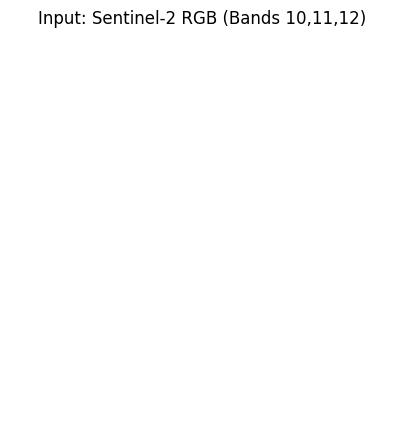

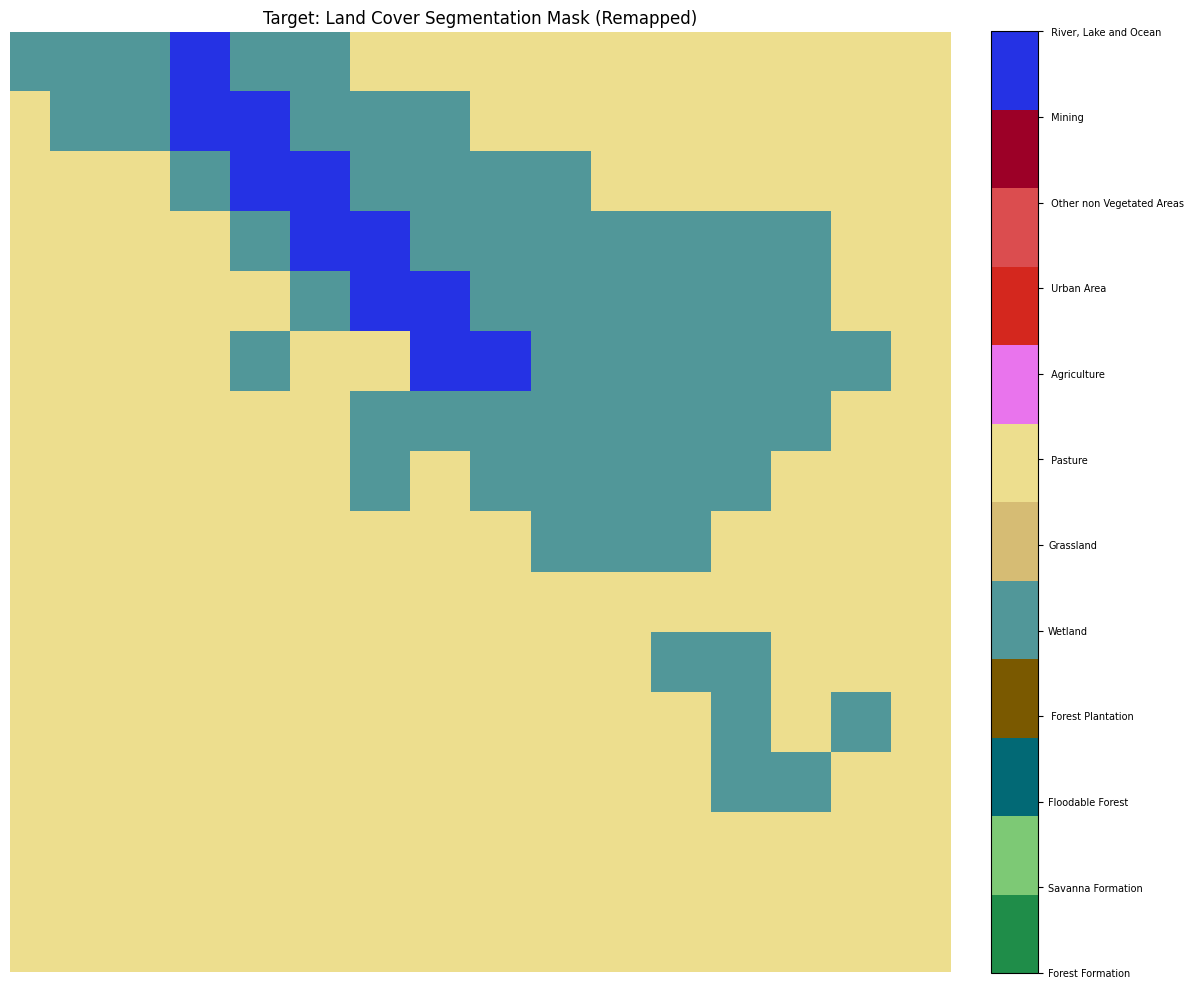

In [25]:
# Visualization with remapped labels
dataset_train = AmazonDataset(data_root, split="train", normalize=True)

# draw a random sample
idx = torch.randint(0, len(dataset_train), (1,)).item()
data, target = dataset_train[idx]
print(f'Image tensor size: {data.size()}')
print(f'Label tensor size: {target.size()}')
print(f'Unique labels in image: {torch.unique(target).numpy()}')

# Visualize RGB (Sentinel-2 bands)
plt.figure(figsize=(10, 5))
rgb = data[9:12, ...].permute(1, 2, 0).numpy()
plt.imshow(np.clip(rgb, 0, 1))
plt.title('Input: Sentinel-2 RGB (Bands 10,11,12)')
plt.axis('off')
plt.show()

# Visualize segmentation mask with remapped colormap
fig, ax = plt.subplots(figsize=(12, 10))
# Mask out -100 values for visualization
target_vis = target.numpy().copy()
target_vis[target_vis == -100] = 0  # Show as black
im = ax.imshow(target_vis, cmap=custom_cmap_remapped, vmin=0, vmax=NUM_CLASSES-1)
ax.axis('off')
ax.set_title('Target: Land Cover Segmentation Mask (Remapped)')

# Add colorbar with remapped class names
cbar = fig.colorbar(im, ax=ax, ticks=class_indices, fraction=0.046, pad=0.04)
cbar.ax.set_yticklabels(class_names_remapped, fontsize=7)
plt.tight_layout()
plt.show()

### Data loader

In [27]:
def load_dataloader(batch_size, split='train', normalize=True):
    """
    Creates a DataLoader for the Amazon dataset.

    Args:
        batch_size (int): Number of samples per batch
        split (str): One of 'train', 'val', or 'test'
        normalize (bool): Whether to apply normalization using S2_MEAN and S2_STD

    Returns:
        DataLoader: PyTorch DataLoader for the specified split
    """
    return DataLoader(
        AmazonDataset(data_root, split=split, normalize=normalize),
        batch_size=batch_size,
        shuffle=(split == 'train'),  # Only shuffle training data
        num_workers=2,                # Use 2 CPU threads for parallel data loading
    )

### Compute class weights for imbalanced class handeling

In [28]:
def compute_class_weights(data_root, split="train"):
    """Compute inverse frequency weights for class balancing"""
    from collections import Counter

    dataset = AmazonDataset(data_root, split=split, normalize=True)
    class_counts = Counter()

    print("Computing class weights...")
    for idx in range(len(dataset)):
        _, labels = dataset[idx]
        unique, counts = torch.unique(labels, return_counts=True)
        for u, c in zip(unique.numpy(), counts.numpy()):
            if u >= 0:  # Skip -100 if any
                class_counts[u] += c

    # Compute inverse frequency weights
    total = sum(class_counts.values())
    weights = torch.zeros(NUM_CLASSES)
    for cls_idx in range(NUM_CLASSES):
        if cls_idx in class_counts:
            weights[cls_idx] = total / (NUM_CLASSES * class_counts[cls_idx])

    # Normalize weights
    weights = weights / weights.sum() * NUM_CLASSES

    print("Class weights:", weights)
    return weights

### Model: UNet

In [45]:
# UNet with pretrained ResNet50 encoder
# This replaces the manual UNet implementation
import segmentation_models_pytorch as smp

# No embeddings, just 12 Sentinel-2 bands
in_channels = 12

model = smp.Unet(
    encoder_name="resnet50",           # Use ResNet50 as the encoder (feature extractor)
    encoder_weights="imagenet",        # Use weights pretrained on ImageNet
    in_channels=in_channels,           # 12 Sentinel-2 bands
    classes=NUM_CLASSES,               # Your number of output classes
    activation=None,                   # No activation (CrossEntropyLoss applies softmax)
)

print(f"✓ Model: UNet with ResNet50 encoder")
print(f"✓ Input channels: {in_channels}")
print(f"✓ Output classes: {NUM_CLASSES}")
print(f"✓ Pretrained: Yes (ImageNet)")

✓ Model: UNet with ResNet50 encoder
✓ Input channels: 12
✓ Output classes: 12
✓ Pretrained: Yes (ImageNet)


In [47]:
for param in model.encoder.parameters():
    param.requires_grad = True

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total trainable parameters: {total_params:,}")

Total trainable parameters: 32,550,924


In [30]:
# use the model
dataloader_train = load_dataloader(batch_size=4, split="train", normalize=True)
data,_ = iter(dataloader_train).__next__()
pred = model(data)

Filtering train images to only include valid classes...
train split has 3550 valid samples (filtered from 4000 total).


In [31]:
assert pred.size(1) == NUM_CLASSES, f'ERROR: invalid number of model output channels (should be # classes {NUM_CLASSES}, got {pred.size(1)})'
assert pred.size(2) == data.size(2), f'ERROR: invalid spatial height of model output (should be {data.size(2)}, got {pred.size(2)})'
assert pred.size(3) == data.size(3), f'ERROR: invalid spatial width of model output (should be {data.size(3)}, got {pred.size(3)})'

### Model training

In [32]:
import torch.nn as nn
criterion = nn.CrossEntropyLoss()
########### should use weighted loss here to handle class imbalance???

# Compute and use weighted loss
class_weights = compute_class_weights(data_root, split="train")
criterion = nn.CrossEntropyLoss(weight=class_weights.to(device))

Filtering train images to only include valid classes...
train split has 3550 valid samples (filtered from 4000 total).
Computing class weights...
Class weights: tensor([1.7818e-03, 2.1668e-02, 3.3049e-03, 2.4006e-01, 1.4045e-02, 2.1920e-02,
        2.1010e-03, 4.0959e-03, 1.5023e-01, 1.1256e+01, 2.5940e-01, 2.5879e-02])


In [33]:
from torch.optim import SGD

def setup_optimiser(model, learning_rate, weight_decay):
  return SGD(
    model.parameters(),
    lr=learning_rate,
    weight_decay=weight_decay
  )

In [34]:
### Better to use Adam optimizer (why???)
from torch.optim import Adam, AdamW
#from torch.optim.lr_scheduler import ReduceLROnPlateau

def setup_optimiser(model, learning_rate, weight_decay):
    # Use Adam instead of SGD
    return AdamW(
        model.parameters(),
        lr=learning_rate,
        weight_decay=weight_decay
    )

In [35]:
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR

def setup_optimiser_and_scheduler(model, learning_rate, weight_decay, num_epochs):
    """
    Setup AdamW optimizer and cosine annealing scheduler

    Args:
        model: the neural network
        learning_rate: initial learning rate
        weight_decay: L2 regularization strength
        num_epochs: total number of training epochs

    Returns:
        optimizer, scheduler
    """
    optimizer = AdamW(
        model.parameters(),
        lr=learning_rate,
        weight_decay=weight_decay
    )

    # Cosine annealing: gradually reduces LR from initial to eta_min
    scheduler = CosineAnnealingLR(
        optimizer,
        T_max=num_epochs,    # Number of epochs for one cycle
        eta_min=1e-6         # Minimum learning rate
    )

    return optimizer, scheduler

In [36]:
from tqdm.notebook import trange      # pretty progress bar

def train_epoch(data_loader, model, optimiser, device):

  # set model to training mode. This is important because some layers behave differently during training and testing
  model.train(True)
  model.to(device)

  # stats
  loss_total = 0.0
  oa_total = 0.0

  # iterate over dataset
  pBar = trange(len(data_loader))
  for idx, (data, target) in enumerate(data_loader):

    #TODO: implement the training step here. Check the introductory slides if you need help.

    # put data and target onto correct device
    data, target = data.to(device), target.to(device)

    # reset gradients
    optimiser.zero_grad()

    # forward pass
    pred = model(data)

    # loss
    loss = criterion(pred, target)

    # backward pass
    loss.backward()

    # parameter update
    optimiser.step()

    # stats update
    loss_total += loss.item()
    oa_total += torch.mean((pred.argmax(1) == target).float()).item()

    # format progress bar
    pBar.set_description('Loss: {:.2f}, OA: {:.2f}'.format(
      loss_total/(idx+1),
      100 * oa_total/(idx+1)
    ))
    pBar.update(1)

  pBar.close()

  # normalise stats
  loss_total /= len(data_loader)
  oa_total /= len(data_loader)

  return model, loss_total, oa_total

In [37]:

def validate_epoch(data_loader, model, device):       # note: no optimiser needed

  # set model to evaluation mode
  model.train(False)
  model.to(device)

  # stats
  loss_total = 0.0
  oa_total = 0.0

  # iterate over dataset
  pBar = trange(len(data_loader))
  for idx, (data, target) in enumerate(data_loader):
    with torch.no_grad():

      #TODO: likewise, implement the validation routine. This is very similar, but not identical, to the training steps.

      # put data and target onto correct device
      data, target = data.to(device), target.to(device)

      # forward pass
      pred = model(data)

      # loss
      loss = criterion(pred, target)

      # stats update
      loss_total += loss.item()
      oa_total += torch.mean((pred.argmax(1) == target).float()).item()

      # format progress bar
      pBar.set_description('Loss: {:.2f}, OA: {:.2f}'.format(
        loss_total/(idx+1),
        100 * oa_total/(idx+1)
      ))
      pBar.update(1)

  pBar.close()

  # normalise stats
  loss_total /= len(data_loader)
  oa_total /= len(data_loader)

  return loss_total, oa_total

In [38]:
import glob

os.makedirs('cnn_states/UNet', exist_ok=True)

def load_model(epoch='latest'):
  model = smp.UNet()
  modelStates = glob.glob('cnn_states/UNet/*.pth')
  if len(modelStates) and (epoch == 'latest' or epoch > 0):
    modelStates = [int(m.replace('cnn_states/UNet/','').replace('.pth', '')) for m in modelStates]
    if epoch == 'latest':
      epoch = max(modelStates)
    stateDict = torch.load(open(f'cnn_states/UNet/{epoch}.pth', 'rb'), map_location='cpu')
    model.load_state_dict(stateDict)
  else:
    # fresh model
    epoch = 0
  return model, epoch


def save_model(model, epoch):
  torch.save(model.state_dict(), open(f'cnn_states/UNet/{epoch}.pth', 'wb'))

In [53]:
import json

# Create checkpoint directory in data_root (persists on Google Drive if using Colab)
checkpoint_dir = os.path.join(data_root, 'cnn_states')
os.makedirs(checkpoint_dir, exist_ok=True)

def save_checkpoint(model, optimizer, scheduler, epoch, train_losses, val_losses, train_oas, val_oas, best_val_loss):
    """Save complete training checkpoint to data_root/cnn_states"""
    checkpoint = {
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'scheduler_state_dict': scheduler.state_dict(),
        'train_losses': train_losses,
        'val_losses': val_losses,
        'train_oas': train_oas,
        'val_oas': val_oas,
        'best_val_loss': best_val_loss
    }

    checkpoint_path = os.path.join(checkpoint_dir, 'checkpoint_latest.pth')
    torch.save(checkpoint, checkpoint_path)

    # Also save a numbered checkpoint every 10 epochs
    if (epoch + 1) % 10 == 0:
        torch.save(checkpoint, os.path.join(checkpoint_dir, f'checkpoint_epoch_{epoch+1}.pth'))

    print(f"Checkpoint saved at epoch {epoch+1} to {checkpoint_dir}")

def load_checkpoint(model, optimizer=None, scheduler=None):
    """Load checkpoint from data_root/cnn_states and resume training"""
    checkpoint_path = os.path.join(checkpoint_dir, 'checkpoint_latest.pth')

    if not os.path.exists(checkpoint_path):
        print("No checkpoint found, starting from scratch")
        return model, optimizer, scheduler, 0, [], [], [], [], float('inf')

    print(f"Loading checkpoint from {checkpoint_path}")
    checkpoint = torch.load(checkpoint_path, map_location='cpu')

    model.load_state_dict(checkpoint['model_state_dict'])

    if optimizer is not None:
        optimizer.load_state_dict(checkpoint['optimizer_state_dict'])

    if scheduler is not None:
        scheduler.load_state_dict(checkpoint['scheduler_state_dict'])

    epoch = checkpoint['epoch']
    train_losses = checkpoint['train_losses']
    val_losses = checkpoint['val_losses']
    train_oas = checkpoint['train_oas']
    val_oas = checkpoint['val_oas']
    best_val_loss = checkpoint['best_val_loss']

    print(f"✓ Resumed from epoch {epoch+1}")
    print(f"✓ Best validation loss so far: {best_val_loss:.4f}")

    return model, optimizer, scheduler, epoch, train_losses, val_losses, train_oas, val_oas, best_val_loss

### Define hyperparameters

In [49]:
device = 'cuda' if torch.cuda.is_available() else 'cpu' ### ??
start_epoch = 0        # set to 0 to start from scratch again or to 'latest' to continue training from saved checkpoint
batch_size = 2
learning_rate = 0.1
weight_decay = 0.001
num_epochs = 10

### OPTIMISATION
batch_size = 4  # Increase if you have GPU memory
learning_rate = 1e-3    # 0.0001 - good for Adam with pretrained model
weight_decay = 1e-4     # 0.0001 - light regularization
num_epochs = 100       # Train longer for better results

In [ ]:
# initialise data loaders
dl_train = load_dataloader(batch_size, 'train')
dl_val = load_dataloader(batch_size, 'val')

# load model
# model, epoch = load_model(epoch=start_epoch)
model = model.to(device)
epoch = start_epoch
optimizer, scheduler = setup_optimiser_and_scheduler(model, learning_rate, weight_decay, num_epochs)

# try to resume from checkpoint
model, optimizer, scheduler, epoch, train_losses, val_losses, train_oas, val_oas, best_val_loss = load_checkpoint(model, optimizer, scheduler)
model = model.to(device)

# Compute class weights for loss
class_weights = compute_class_weights(data_root, split="train")
criterion = nn.CrossEntropyLoss(weight=class_weights.to(device))


# Print class weights with class names
print(f"\n{'='*80}")
print(f"CLASS WEIGHTS SUMMARY")
print(f"{'='*80}")
print(f"{'Index':<8} {'Original ID':<12} {'Class Name':<40} {'Weight':<10}")
print(f"{'-'*80}")

for new_idx in range(NUM_CLASSES):
    orig_id = index_to_class_id[new_idx]
    class_name = class_names_remapped[new_idx]
    weight = class_weights[new_idx].item()
    print(f"{new_idx:<8} {orig_id:<12} {class_name:<40} {weight:<10.4f}")

print(f"{'-'*80}")
print(f"Min weight: {class_weights.min().item():.4f}")
print(f"Max weight: {class_weights.max().item():.4f}")
print(f"Mean weight: {class_weights.mean().item():.4f}")
print(f"{'='*80}\n")


max_weight = 1.0  # Cap extreme weights
class_weights = torch.clamp(class_weights, max=max_weight)
print(f"Class weights (capped at {max_weight}):", class_weights)



# Training loop with history tracking
epoch = start_epoch
best_val_loss = float('inf')

# Lists to track training history
train_losses = []
val_losses = []
train_oas = []
val_oas = []
epochs_list = []

# do epochs
while epoch < num_epochs:

  # training
  model, loss_train, oa_train = train_epoch(dl_train, model, optimizer, device)

  # validation
  loss_val, oa_val = validate_epoch(dl_val, model, device)

  # Step the scheduler (update learning rate)
  scheduler.step()

  # Store metrics
  train_losses.append(loss_train)
  val_losses.append(loss_val)
  train_oas.append(oa_train)
  val_oas.append(oa_val)
  epochs_list.append(epoch + 1)

  # Print stats
  current_lr = optimizer.param_groups[0]['lr']
  print('[Ep. {}/{}] Loss train: {:.2f}, val: {:.2f}; OA train: {:.2f}, val: {:.2f}; LR: {:.6f}'.format(
      epoch+1, num_epochs,
      loss_train, loss_val,
      100*oa_train, 100*oa_val,
      current_lr
    ))

  # Save best model
  if loss_val < best_val_loss:
      best_val_loss = loss_val
      save_model(model, epoch+1)

  epoch += 1
  save_checkpoint(model, optimizer, scheduler, epoch, train_losses, val_losses, train_oas, val_oas, best_val_loss)

Filtering train images to only include valid classes...
train split has 3550 valid samples (filtered from 4000 total).
Filtering val images to only include valid classes...
val split has 892 valid samples (filtered from 1000 total).
No checkpoint found, starting from scratch
Filtering train images to only include valid classes...
train split has 3550 valid samples (filtered from 4000 total).
Computing class weights...
Class weights: tensor([1.7818e-03, 2.1668e-02, 3.3049e-03, 2.4006e-01, 1.4045e-02, 2.1920e-02,
        2.1010e-03, 4.0959e-03, 1.5023e-01, 1.1256e+01, 2.5940e-01, 2.5879e-02])

CLASS WEIGHTS SUMMARY
Index    Original ID  Class Name                               Weight    
--------------------------------------------------------------------------------
0        3            Forest Formation                         0.0018    
1        4            Savanna Formation                        0.0217    
2        6            Floodable Forest                         0.0033    
3 

  0%|          | 0/888 [00:00<?, ?it/s]

  0%|          | 0/223 [00:00<?, ?it/s]

[Ep. 1/100] Loss train: 1.50, val: 1.61; OA train: 50.01, val: 44.66; LR: 0.001000
💾 Checkpoint saved at epoch 2 to /content/drive/MyDrive/IPEO_DeepL_data/cnn_states


  0%|          | 0/888 [00:00<?, ?it/s]

  0%|          | 0/223 [00:00<?, ?it/s]

[Ep. 2/100] Loss train: 1.46, val: 1.42; OA train: 50.59, val: 51.24; LR: 0.000999
💾 Checkpoint saved at epoch 3 to /content/drive/MyDrive/IPEO_DeepL_data/cnn_states


  0%|          | 0/888 [00:00<?, ?it/s]

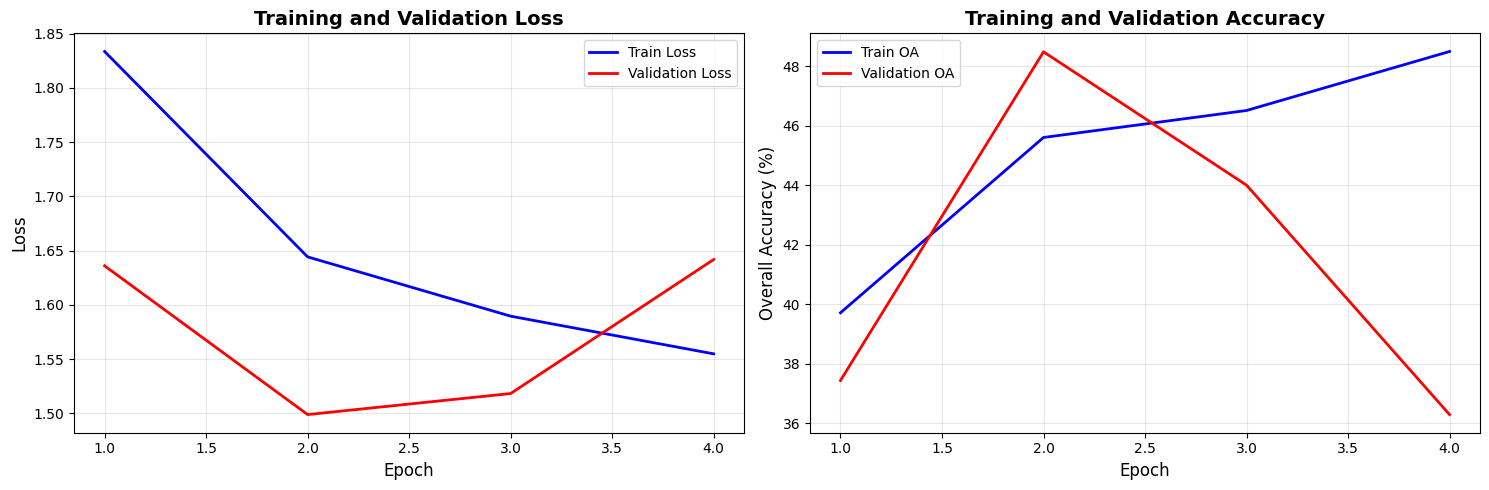


Training Summary:
Best Validation Loss: 1.4988
Final Train Loss: 1.5548 | Final Val Loss: 1.6418
Final Train OA: 48.49% | Final Val OA: 36.30%


In [51]:
# Plot training history
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Plot losses
ax1.plot(epochs_list, train_losses, 'b-', label='Train Loss', linewidth=2)
ax1.plot(epochs_list, val_losses, 'r-', label='Validation Loss', linewidth=2)
ax1.set_xlabel('Epoch', fontsize=12)
ax1.set_ylabel('Loss', fontsize=12)
ax1.set_title('Training and Validation Loss', fontsize=14, fontweight='bold')
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)

# Plot accuracies
ax2.plot(epochs_list, [100*oa for oa in train_oas], 'b-', label='Train OA', linewidth=2)
ax2.plot(epochs_list, [100*oa for oa in val_oas], 'r-', label='Validation OA', linewidth=2)
ax2.set_xlabel('Epoch', fontsize=12)
ax2.set_ylabel('Overall Accuracy (%)', fontsize=12)
ax2.set_title('Training and Validation Accuracy', fontsize=14, fontweight='bold')
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print summary
print(f"\n{'='*60}")
print(f"Training Summary:")
print(f"{'='*60}")
print(f"Best Validation Loss: {best_val_loss:.4f}")
print(f"Final Train Loss: {train_losses[-1]:.4f} | Final Val Loss: {val_losses[-1]:.4f}")
print(f"Final Train OA: {100*train_oas[-1]:.2f}% | Final Val OA: {100*val_oas[-1]:.2f}%")
print(f"{'='*60}")